<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 8</b></center>    
<pre>    

# import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Import diabetes.csv data ser using sklearn

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


# Check the distribution of the target

In [8]:
print(df['Outcome'].value_counts())

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64


# Replace zeros with NaN for specific columns

In [9]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Diabetic
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,Non Diabetic
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Diabetic
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,Non Diabetic
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetic


In [10]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [11]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

/var/folders/43/k4sdnl7s62563fydpsnbkshh0000gn/T/ipykernel_1216/1805888609.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Visualize Distributions

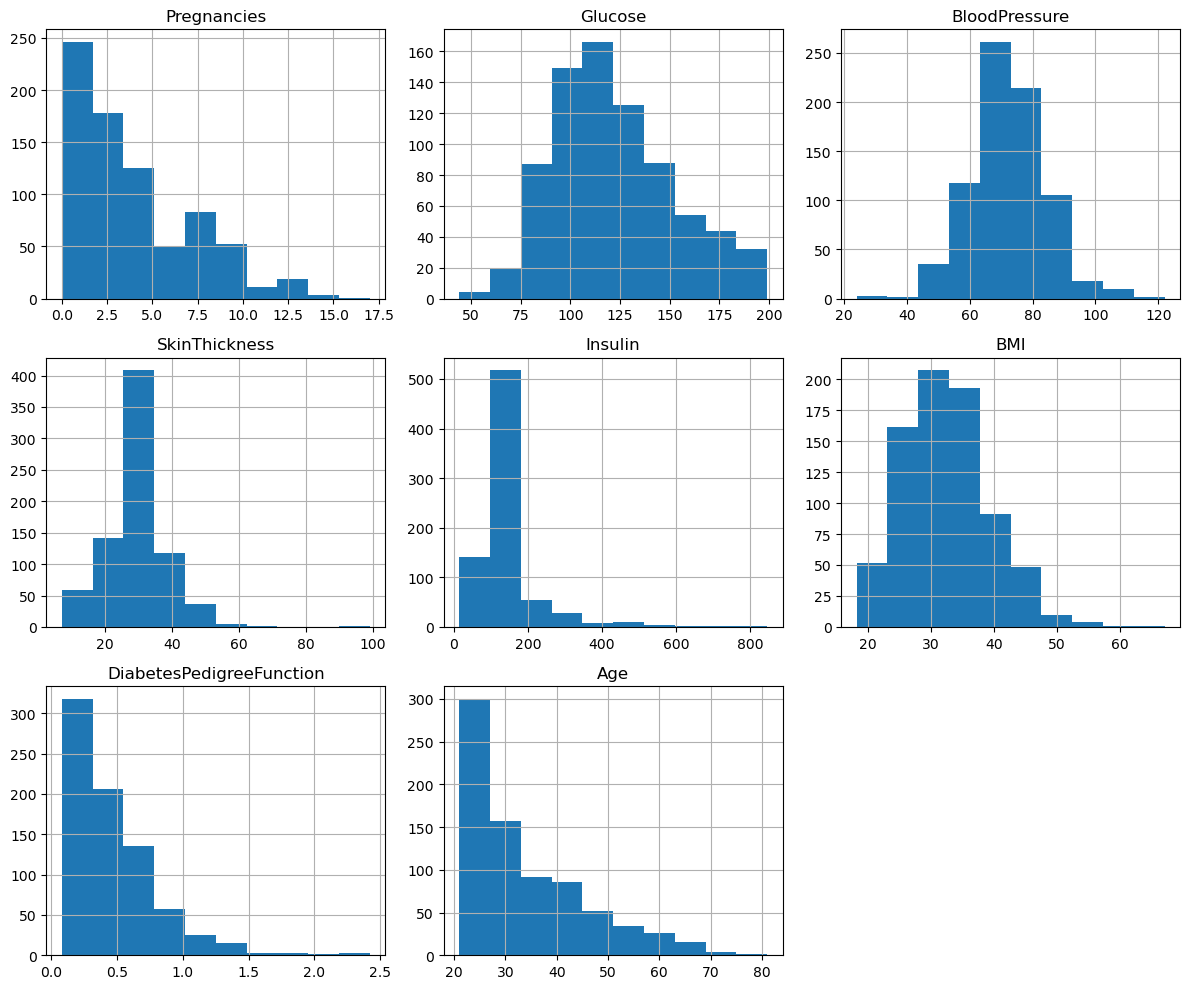

In [13]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Convert Targer data into interger code

In [14]:
df['Outcome'].unique()

array(['Diabetic', 'Non Diabetic'], dtype=object)

In [15]:
le = LabelEncoder()
df['Outcome'] = le.fit_transform(df['Outcome'])

# Divide the data into input and output

In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(X.shape)
print(y.shape)

(768, 8)
(768,)


# Splitting the dataset into the Training set and Test set

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

(614, 8)
(154, 8)


In [20]:
X_train.shape

(614, 8)

In [19]:
X_test.shape

(154, 8)

# Create Model

In [54]:
model = DecisionTreeClassifier(max_depth=2,random_state=42)

In [52]:
for depth in range(1,11):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    print(
        f"Depth={depth} | "
        f"Train={model.score(X_train,y_train):.3f} | "
        f"Test={model.score(X_test,y_test):.3f}"
    )

Depth=1 | Train=0.735 | Test=0.740
Depth=2 | Train=0.770 | Test=0.773
Depth=3 | Train=0.775 | Test=0.760
Depth=4 | Train=0.803 | Test=0.708
Depth=5 | Train=0.837 | Test=0.727
Depth=6 | Train=0.871 | Test=0.727
Depth=7 | Train=0.894 | Test=0.721
Depth=8 | Train=0.912 | Test=0.727
Depth=9 | Train=0.932 | Test=0.747
Depth=10 | Train=0.948 | Test=0.714


# Fitting DecisionTreeClassifier   on dataset

In [55]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

# Display Decision Tree

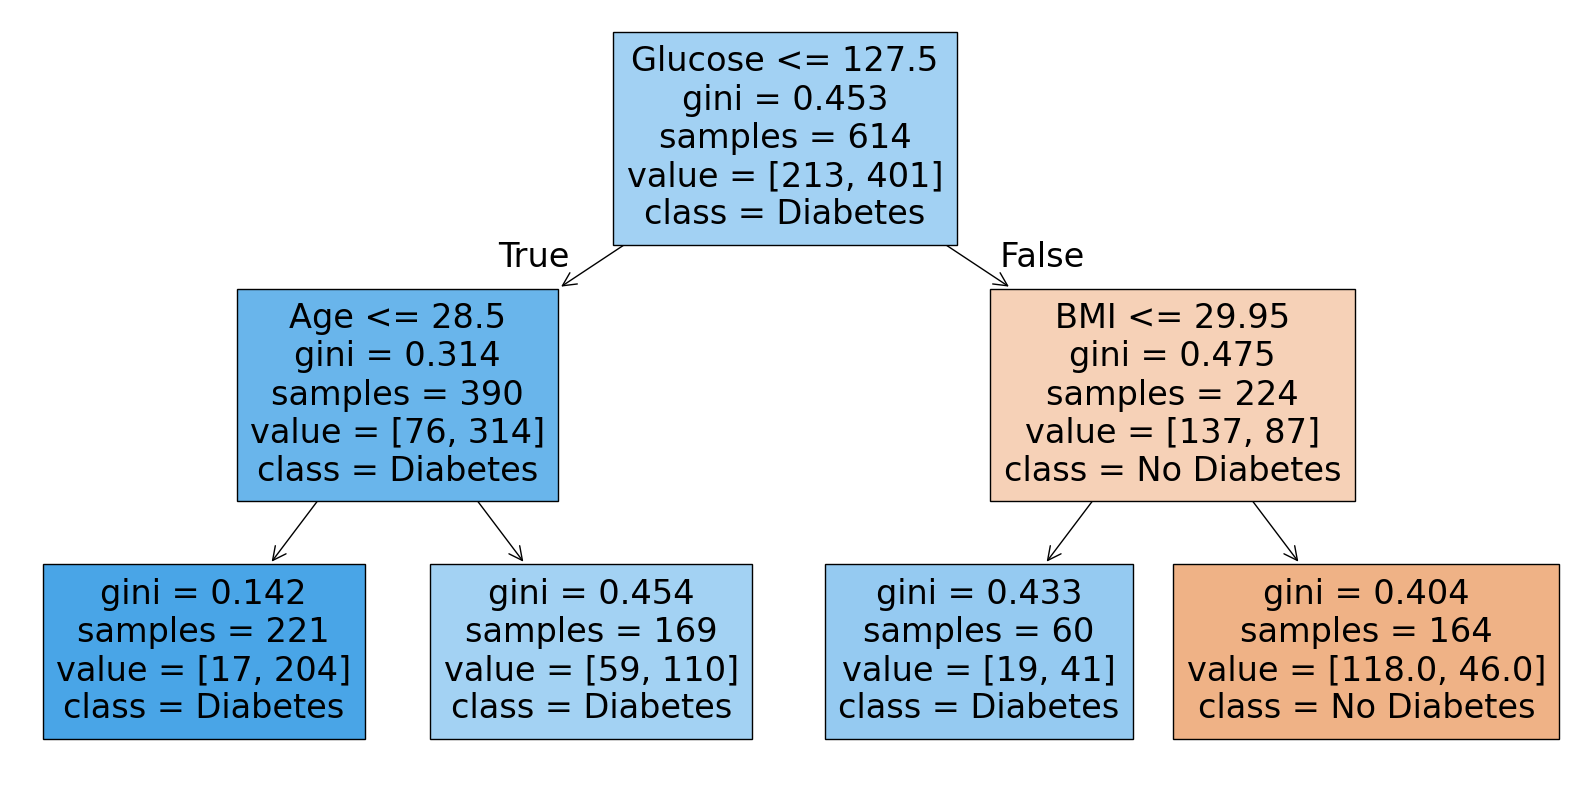

In [56]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True
)

plt.show()

# Predict the x_test 

In [57]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 1 0 0
 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1
 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1
 1 0 1 1 1 1]


# Display Training Accuracy

In [58]:
train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy :", train_acc)

Training Accuracy : 0.7703583061889251


# Display Test Accuracy

In [59]:
test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy :", test_acc)

Test Accuracy : 0.7727272727272727
